In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn.preprocessing import normalize, StandardScaler

In [5]:
X = pd.read_csv('uenaka_feature_cluster_issue.csv')
X

,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_302,f_303,f_304,f_305,f_306,f_307,f_308,f_309,f_310,f_311
0,0.040723,0.019824,0.029126,0.071094,-0.069629,-0.019604,-0.006226,-0.022266,0.132910,0.199219,...,0.986842,0.978902,0.986842,0.986842,0.996933,0.879224,0.993160,0.986415,0.988414,0.994716
1,0.119995,0.068921,0.018826,0.127344,-0.117456,0.053284,0.168262,0.011890,0.050000,0.074365,...,0.984127,0.949707,0.960317,0.984127,0.999874,0.708649,0.990073,0.981152,0.983396,0.993543
2,0.176758,-0.080566,0.058594,-0.089844,-0.243164,0.079590,0.043457,0.239258,0.503906,0.167969,...,0.986842,0.952259,0.947368,0.986842,0.999965,0.992051,0.999615,0.999419,0.999335,0.999840
3,0.066406,-0.012533,-0.023966,0.097005,-0.107727,-0.026855,-0.019714,-0.051758,0.257243,0.188477,...,0.973684,0.958392,0.960526,0.973684,0.999998,0.937843,0.996081,0.990604,0.989941,0.998189
4,0.038411,-0.023356,-0.024170,0.070231,-0.056966,0.010498,-0.013346,0.107096,0.256348,0.091797,...,0.582781,0.584504,0.417219,0.768212,0.999997,0.820986,0.999613,0.995765,0.999052,0.999858
5,0.078491,0.003784,-0.007233,0.073875,-0.012436,-0.002197,0.028671,-0.088379,0.198120,0.171021,...,0.941176,0.903770,0.901961,0.960784,0.999980,0.969836,0.998802,0.996724,0.996652,0.999590
6,0.013184,-0.086670,0.044617,0.060059,-0.156982,-0.002686,-0.035889,-0.005371,0.409180,0.223633,...,0.921569,0.853601,0.784314,0.980392,0.999726,0.939854,0.998062,0.994030,0.992506,0.998763
7,0.078125,0.009521,0.006177,0.223828,-0.111328,-0.061206,0.031836,-0.077148,0.165521,0.202539,...,0.944444,0.924500,0.912698,0.960317,0.999749,0.832873,0.995384,0.989129,0.992223,0.997904
8,0.013184,-0.086670,0.044617,0.060059,-0.156982,-0.002686,-0.035889,-0.005371,0.409180,0.223633,...,0.900990,0.872320,0.871287,0.920792,0.999920,0.803759,0.996425,0.992367,0.992199,0.998087
9,0.035482,-0.067139,0.008341,0.003906,-0.134583,-0.094808,0.058675,-0.041992,0.207520,0.097738,...,0.960317,0.951753,0.944444,0.968254,0.999984,0.784111,0.990768,0.981115,0.982767,0.995382


In [6]:
# Scaling the data to bring all the attributes to a comparable level
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Normalizing the data so that the data
# approximately follows a Gaussian distribution
X_normalized = normalize(X_scaled)

# Converting the numpy array into a pandas DataFrame
X_normalized = pd.DataFrame(X_normalized)

# Renaming the columns
X_normalized.columns = X.columns

X_normalized.head()


,f_0,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,f_302,f_303,f_304,f_305,f_306,f_307,f_308,f_309,f_310,f_311
0,-0.072335,0.057564,0.067943,-0.018518,0.072768,0.003439,-0.017791,-0.005100,-0.026525,0.064137,...,0.053612,0.061756,0.062888,0.048142,-0.240536,0.040858,-0.041504,0.023421,0.018164,-0.092279
1,0.023186,0.107937,0.047666,0.027014,0.019161,0.087728,0.133829,0.022560,-0.063906,-0.079855,...,0.044780,0.041080,0.045335,0.039807,0.026973,-0.001004,-0.098243,0.003739,0.001113,-0.113757
2,0.042464,-0.035961,0.044240,-0.069927,-0.047375,0.059827,0.013775,0.101983,0.081919,0.010642,...,0.023132,0.021283,0.020863,0.020772,0.017298,0.029626,0.048504,0.030403,0.023671,0.037497
3,-0.037412,0.011334,0.005247,0.004286,0.030498,-0.006014,-0.029193,-0.030165,0.042912,0.047182,...,0.044865,0.048693,0.049636,0.038150,0.040242,0.051600,0.026267,0.035991,0.021735,0.027207
4,-0.071438,-0.002891,0.005113,-0.018314,0.081744,0.042229,-0.023659,0.108567,0.043175,-0.067941,...,-0.110256,-0.116065,-0.139435,-0.068734,0.040869,0.025169,0.106712,0.054355,0.051189,0.083096


Visualizing the results

In [7]:
from sklearn.neighbors import NearestNeighbors # importing the library
neighb = NearestNeighbors(n_neighbors=2) # creating an object of the NearestNeighbors class, which can be same as the minPts value
nbrs=neighb.fit(X) # fitting the data to the object
distances,indices=nbrs.kneighbors(X)

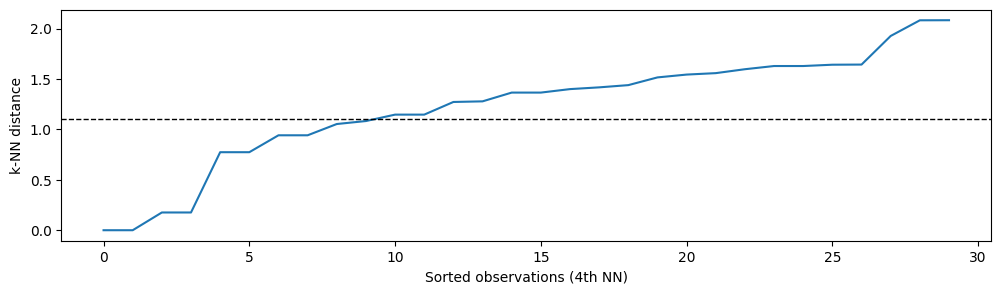

0.17602683623487153


In [8]:
# Sort and plot the distances results
distances = np.sort(distances, axis = 0) # sorting the distances
distances = distances[:, 1] # taking the second column of the sorted distances
plt.rcParams['figure.figsize'] = (12,3) # setting the figure size
plt.plot(distances) # plotting the distances
plt.axhline(y=1.1, linewidth=1, linestyle='dashed', color='k')
plt.ylabel("k-NN distance")
plt.xlabel("Sorted observations (4th NN)")
plt.show()
best = 0
best_delta = 0
for i in range(0, len(distances)):
  if distances[i] - distances[i-1] > best_delta:
    best_delta = distances[i] - distances[i-1]
    best = distances[i-1]

print(best)

In [9]:
# Building the OPTICS Clustering model
optics_model = OPTICS(min_samples =2, max_eps=best, metric='euclidean')

# Training the model
optics_model.fit(X)

OPTICS_dataset = X.copy()
OPTICS_dataset.loc[:,'Cluster'] = optics_model.labels_

In [10]:
labels = optics_model.labels_
print(labels)
# Number of clusters in labels, ignoring noise if present.
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print("Estimated number of clusters: %d" % n_clusters_)
print("Estimated number of noise points: %d" % n_noise_)

[-1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1 -1  0
  0 -1 -1 -1 -1 -1]
Estimated number of clusters: 1
Estimated number of noise points: 28


In [201]:
OPTICS_dataset.Cluster.to_frame()

,Cluster
0,0
1,0
